# Search Demand Growth Movers by Country

This notebook analyzes changes in AI brand search demand across countries using the project's popularity summary data.

For each category, it identifies the top risers and fallers by year-over-year (YoY) search-demand change. The worldwide (`WW`) scope is excluded from country-level analysis.

To reduce noise from very small brands, only brands with at least 10,000 average monthly searches are included.

The analysis describes search-demand changes and should not be interpreted as market share.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data/popularity/csv")

if not DATA_DIR.exists():
    DATA_DIR = Path("../data/popularity/csv")

if not DATA_DIR.exists():
    raise FileNotFoundError("Could not find data/popularity/csv")

CATEGORIES = ["ai", "coding","apps","crypto","design","formats","languages","nocode","seo","storage"]
SEARCH_VOLUME_PERCENTILE = 0.30
TOP_N = 4

In [11]:
category_data = {}

for category in CATEGORIES:
    path = DATA_DIR / f"popularity-{category}-summary.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing category file: {path}")

    category_data[category] = pd.read_csv(path)

category_data

{'ai':     snapshot category scope  rank           brand         vendor  \
 0    2026-07       ai    WW     1         ChatGPT         OpenAI   
 1    2026-07       ai    WW     2          Gemini         Google   
 2    2026-07       ai    WW     3          Claude      Anthropic   
 3    2026-07       ai    WW     4            Grok            xAI   
 4    2026-07       ai    WW     5      Perplexity  Perplexity AI   
 ..       ...      ...   ...   ...             ...            ...   
 268  2026-07       ai    SA     9         Copilot      Microsoft   
 269  2026-07       ai    SA    10            Qwen        Alibaba   
 270  2026-07       ai    SA    11  GitHub Copilot         GitHub   
 271  2026-07       ai    SA    12         Mistral     Mistral AI   
 272  2026-07       ai    SA    13          Doubao      ByteDance   
 
      avg_monthly_searches  share_pct  mom_pct  yoy_pct  
 0               776290000       82.7     -6.4     26.4  
 1               103228000       11.0     -9.1  

In [12]:
for category, data in category_data.items():
    print(f"{category.upper()}: {len(data)} rows")
    print(data.columns.tolist())
    print()

AI: 273 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

CODING: 336 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

APPS: 336 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

CRYPTO: 336 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

DESIGN: 336 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

FORMATS: 252 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

LANGUAGES: 294 rows
['snapshot', 'category', 'scope', 'rank', 'brand', 'vendor', 'avg_monthly_searches', 'share_pct', 'mom_pct', 'yoy_pct']

NOCODE: 336 rows
['snapshot', 'categ

In [13]:
def get_growth_movers(data, volume_percentile=0.30, top_n=4):
    country_data = data[data["scope"] != "WW"].copy()

    min_searches = country_data["avg_monthly_searches"].quantile(
        volume_percentile
    )

    filtered = country_data[
        country_data["avg_monthly_searches"] >= min_searches
    ].copy()

    risers = (
        filtered
        .sort_values(["scope", "yoy_pct"], ascending=[True, False])
        .groupby("scope")
        .head(top_n)
        .copy()
    )

    fallers = (
        filtered
        .sort_values(["scope", "yoy_pct"], ascending=[True, True])
        .groupby("scope")
        .head(top_n)
        .copy()
    )

    return filtered, risers, fallers, min_searches

In [14]:
results = {}

for category, data in category_data.items():
    filtered, risers, fallers, min_searches = get_growth_movers(
        data,
        volume_percentile=SEARCH_VOLUME_PERCENTILE,
        top_n=TOP_N,
    )

    results[category] = {
        "filtered": filtered,
        "risers": risers,
        "fallers": fallers,
        "min_searches": min_searches,
    }

    print(
        f"{category.upper()}: "
        f"threshold = {min_searches:,.0f} searches/month | "
        f"{len(filtered)} of {len(data[data['scope'] != 'WW'])} rows retained"
    )

AI: threshold = 22,200 searches/month | 184 of 260 rows retained
CODING: threshold = 2,900 searches/month | 229 of 320 rows retained
APPS: threshold = 673,000 searches/month | 229 of 320 rows retained
CRYPTO: threshold = 1,600 searches/month | 228 of 320 rows retained
DESIGN: threshold = 1,900 searches/month | 230 of 320 rows retained
FORMATS: threshold = 2,400 searches/month | 173 of 240 rows retained
LANGUAGES: threshold = 2,250 searches/month | 196 of 280 rows retained
NOCODE: threshold = 1,600 searches/month | 235 of 320 rows retained
SEO: threshold = 557 searches/month | 224 of 320 rows retained
STORAGE: threshold = 3,600 searches/month | 206 of 280 rows retained


In [15]:
for category in CATEGORIES:
    print(f"\n{category.upper()} — TOP RISERS")

    display(
        results[category]["risers"][
            [
                "scope",
                "brand",
                "avg_monthly_searches",
                "yoy_pct",
            ]
        ].sort_values(["scope", "yoy_pct"], ascending=[True, False])
    )


AI — TOP RISERS


,scope,brand,avg_monthly_searches,yoy_pct
66,AU,Claude,550000,1009.1
67,AU,Gemini,450000,233.3
68,AU,Grok,301000,22.4
71,AU,Copilot,40500,22.4
106,BR,Claude,1220000,1566.7
...,...,...,...,...
23,US,Qwen,74000,49.4
224,VN,Claude,368000,509.6
222,VN,Gemini,1000000,395.9
227,VN,Meta AI,74000,49.6



CODING — TOP RISERS


,scope,brand,avg_monthly_searches,yoy_pct
80,AU,Claude Code,49500,49.5
81,AU,VS Code,27100,0.0
83,AU,GitHub Copilot,12100,0.0
88,AU,Xcode,2900,0.0
128,BR,Claude Code,165000,643.2
...,...,...,...,...
19,US,Cursor,110000,0.0
273,VN,Claude Code,40500,123.0
272,VN,VS Code,49500,22.2
275,VN,GitHub Copilot,14800,0.0



APPS — TOP RISERS


...

,scope,brand,avg_monthly_searches,yoy_pct
85,AU,Framer,12100,0.0
87,AU,Power Apps,5400,0.0
88,AU,AppSheet,2400,0.0
89,AU,FlutterFlow,2400,0.0
136,BR,Airtable,14800,22.7
...,...,...,...,...
20,US,Carrd,90500,-17.7
274,VN,Framer,6600,50.0
273,VN,AppSheet,12100,0.0
275,VN,Airtable,4400,0.0



SEO — TOP RISERS


,scope,brand,avg_monthly_searches,yoy_pct
80,AU,Google Search Console,49500,49.5
86,AU,Screaming Frog,1900,0.0
88,AU,SE Ranking,1300,0.0
92,AU,Rank Math,590,-18.1
128,BR,Google Search Console,74000,49.6
...,...,...,...,...
17,US,Semrush,90500,-18.2
276,VN,Screaming Frog,1600,18.8
272,VN,Google Search Console,60500,0.0
273,VN,Semrush,14800,0.0



STORAGE — TOP RISERS


,scope,brand,avg_monthly_searches,yoy_pct
78,AU,Proton Drive,3600,50.0
70,AU,Google Drive,823000,22.3
71,AU,OneDrive,368000,22.3
74,AU,WeTransfer,90500,0.0
123,BR,iDrive,3600,175.0
...,...,...,...,...
17,US,Dropbox,1220000,0.0
238,VN,Google Drive,1000000,21.5
239,VN,iCloud,450000,0.0
243,VN,Terabox,22200,0.0


In [16]:
for category in CATEGORIES:
    print(f"\n{category.upper()} — TOP FALLERS")

    display(
        results[category]["fallers"][
            [
                "scope",
                "brand",
                "avg_monthly_searches",
                "yoy_pct",
            ]
        ].sort_values(["scope", "yoy_pct"], ascending=[True, True])
    )


AI — TOP FALLERS


,scope,brand,avg_monthly_searches,yoy_pct
70,AU,DeepSeek,201000,-45.1
72,AU,Midjourney,33100,-33.1
69,AU,Perplexity,201000,-32.8
65,AU,ChatGPT,16600000,22.1
111,BR,Midjourney,135000,-33.0
...,...,...,...,...
18,US,DeepSeek,1220000,-18.0
228,VN,Midjourney,33100,-32.9
225,VN,DeepSeek,368000,-18.2
226,VN,Perplexity,90500,-18.2



CODING — TOP FALLERS


,scope,brand,avg_monthly_searches,yoy_pct
86,AU,PyCharm,5400,-45.5
85,AU,Visual Studio,8100,-33.3
87,AU,Android Studio,4400,-18.5
84,AU,Cursor,9900,-18.2
141,BR,Windsurf,2900,-46.3
...,...,...,...,...
18,US,Replit,246000,-33.2
278,VN,Cursor,9900,-45.5
279,VN,Sublime Text,9900,-33.3
281,VN,IntelliJ IDEA,6600,-33.3



APPS — TOP FALLERS


...

,scope,brand,avg_monthly_searches,yoy_pct
80,AU,n8n,27100,-63.5
83,AU,Webflow,12100,-33.1
84,AU,Typeform,12100,-33.1
90,AU,Retool,1600,-31.6
140,BR,Adalo,3600,-55.6
...,...,...,...,...
31,US,Bubble,3600,-45.5
276,VN,Zapier,4400,-33.3
272,VN,n8n,27100,-32.9
280,VN,Typeform,1600,-18.7



SEO — TOP FALLERS


,scope,brand,avg_monthly_searches,yoy_pct
87,AU,GTmetrix,1600,-45.8
89,AU,Surfer SEO,1000,-44.6
84,AU,Ubersuggest,3600,-34.1
82,AU,Ahrefs,6600,-33.3
138,BR,Surfer SEO,720,-55.7
...,...,...,...,...
20,US,Ubersuggest,18100,-33.3
277,VN,Ubersuggest,1300,-37.5
274,VN,Similarweb,9900,-33.1
278,VN,AnswerThePublic,1000,-32.3



STORAGE — TOP FALLERS


,scope,brand,avg_monthly_searches,yoy_pct
79,AU,iDrive,3600,-34.1
76,AU,Nextcloud,4400,-18.2
72,AU,iCloud,165000,-17.9
73,AU,Dropbox,165000,-17.9
117,BR,MediaFire,135000,-18.5
...,...,...,...,...
27,US,MEGA,14800,-18.2
242,VN,MediaFire,33100,-18.3
240,VN,OneDrive,135000,-18.2
241,VN,Dropbox,33100,-18.1


In [17]:
all_risers = []
all_fallers = []

for category in CATEGORIES:
    risers = results[category]["risers"].copy()
    fallers = results[category]["fallers"].copy()

    risers["category"] = category.upper()
    fallers["category"] = category.upper()

    all_risers.append(risers)
    all_fallers.append(fallers)

all_risers = pd.concat(all_risers, ignore_index=True)
all_fallers = pd.concat(all_fallers, ignore_index=True)

top_risers = (
    all_risers
    .sort_values("yoy_pct", ascending=False)
    .head(10)
    .copy()
)

top_fallers = (
    all_fallers
    .sort_values("yoy_pct", ascending=True)
    .head(10)
    .copy()
)

top_risers["label"] = (
    top_risers["category"]
    + " | "
    + top_risers["scope"]
    + " | "
    + top_risers["brand"]
)

top_fallers["label"] = (
    top_fallers["category"]
    + " | "
    + top_fallers["scope"]
    + " | "
    + top_fallers["brand"]
)

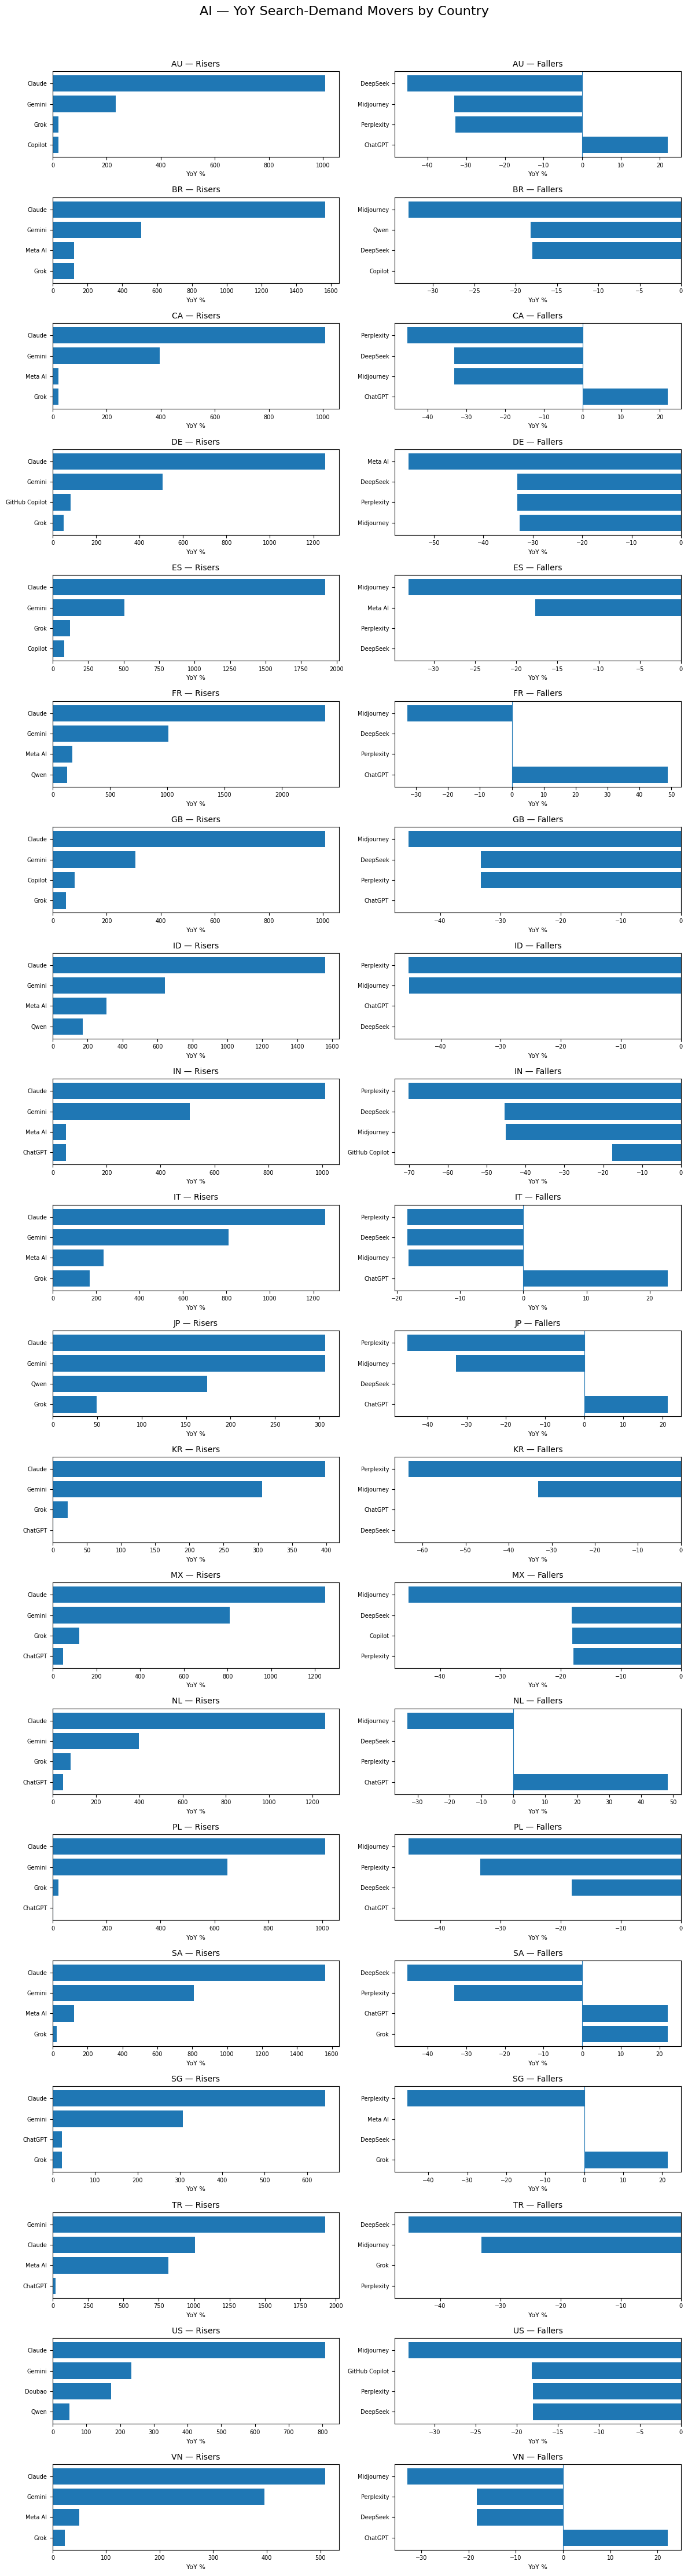

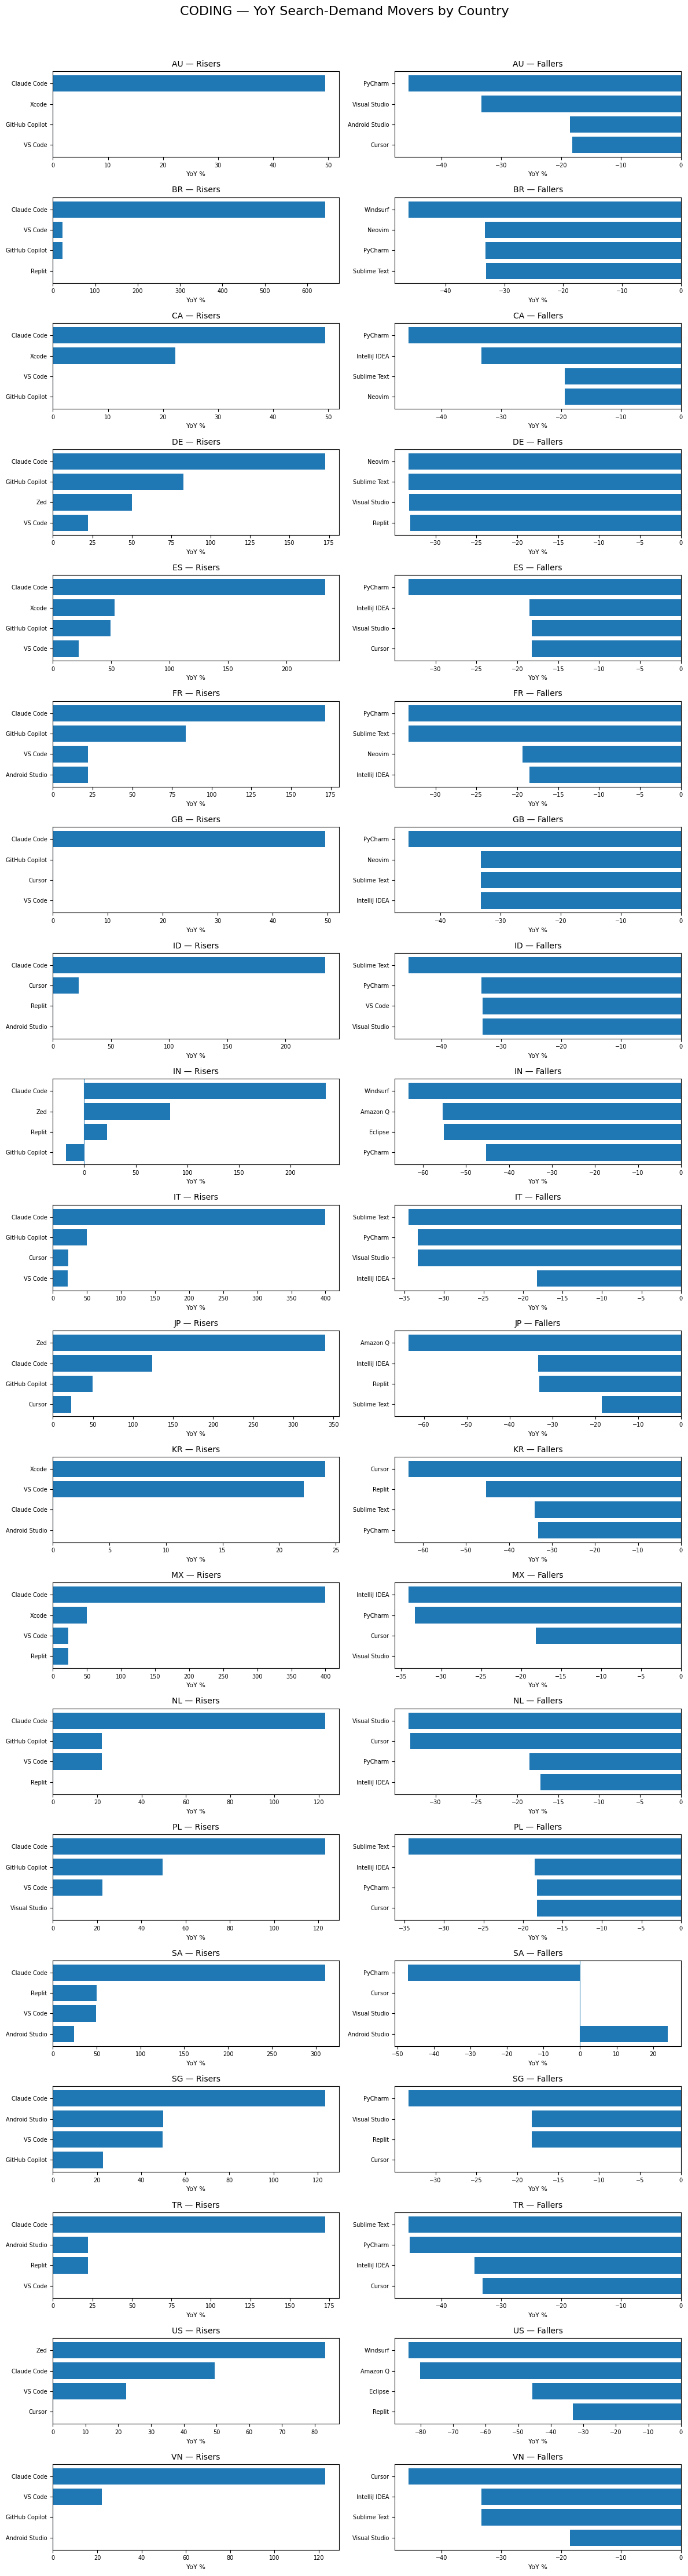

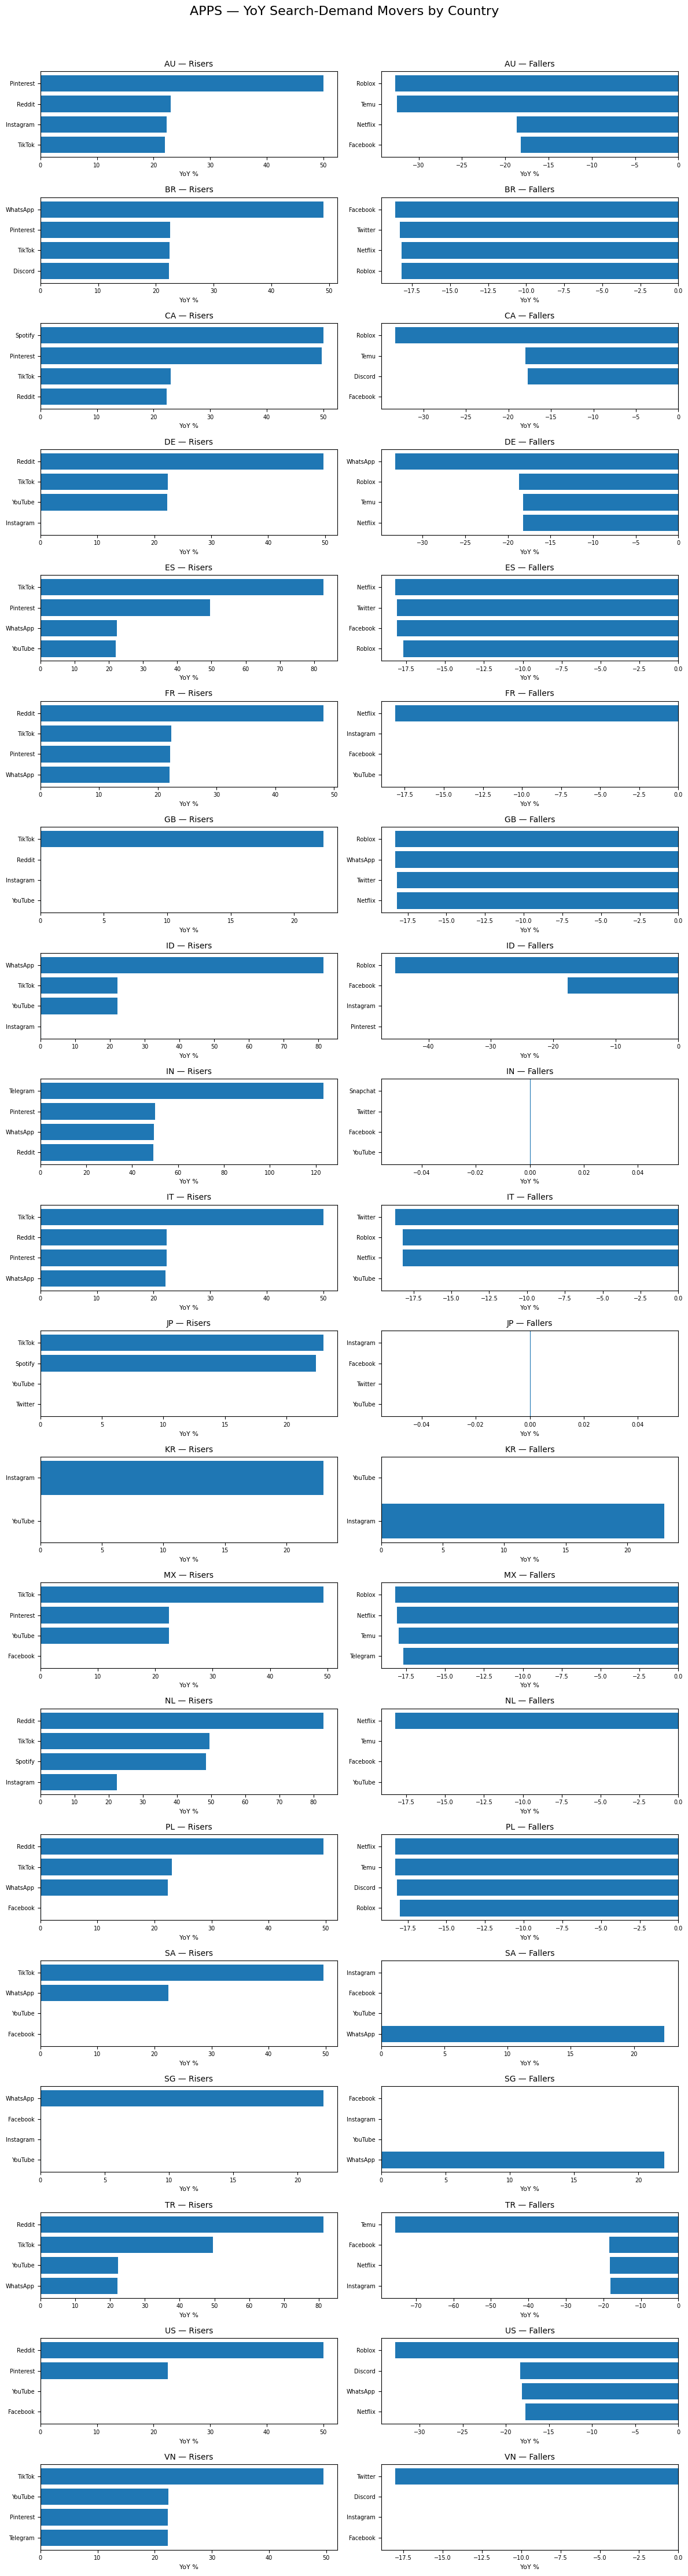

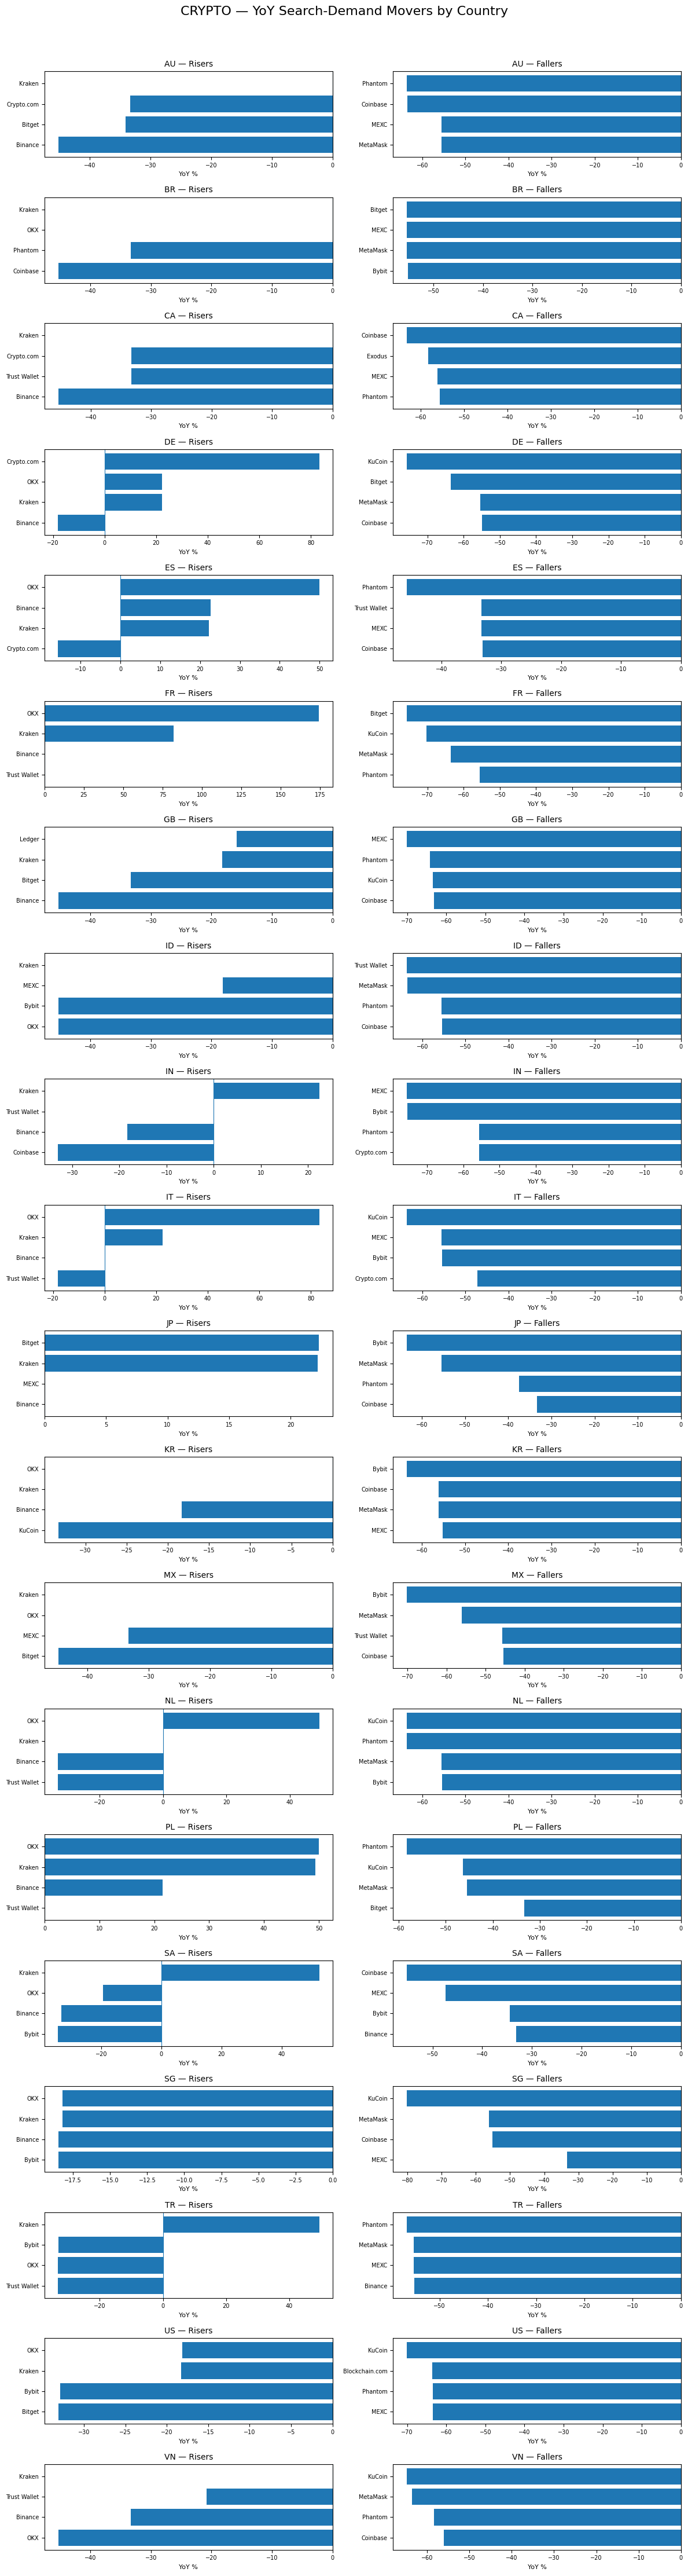

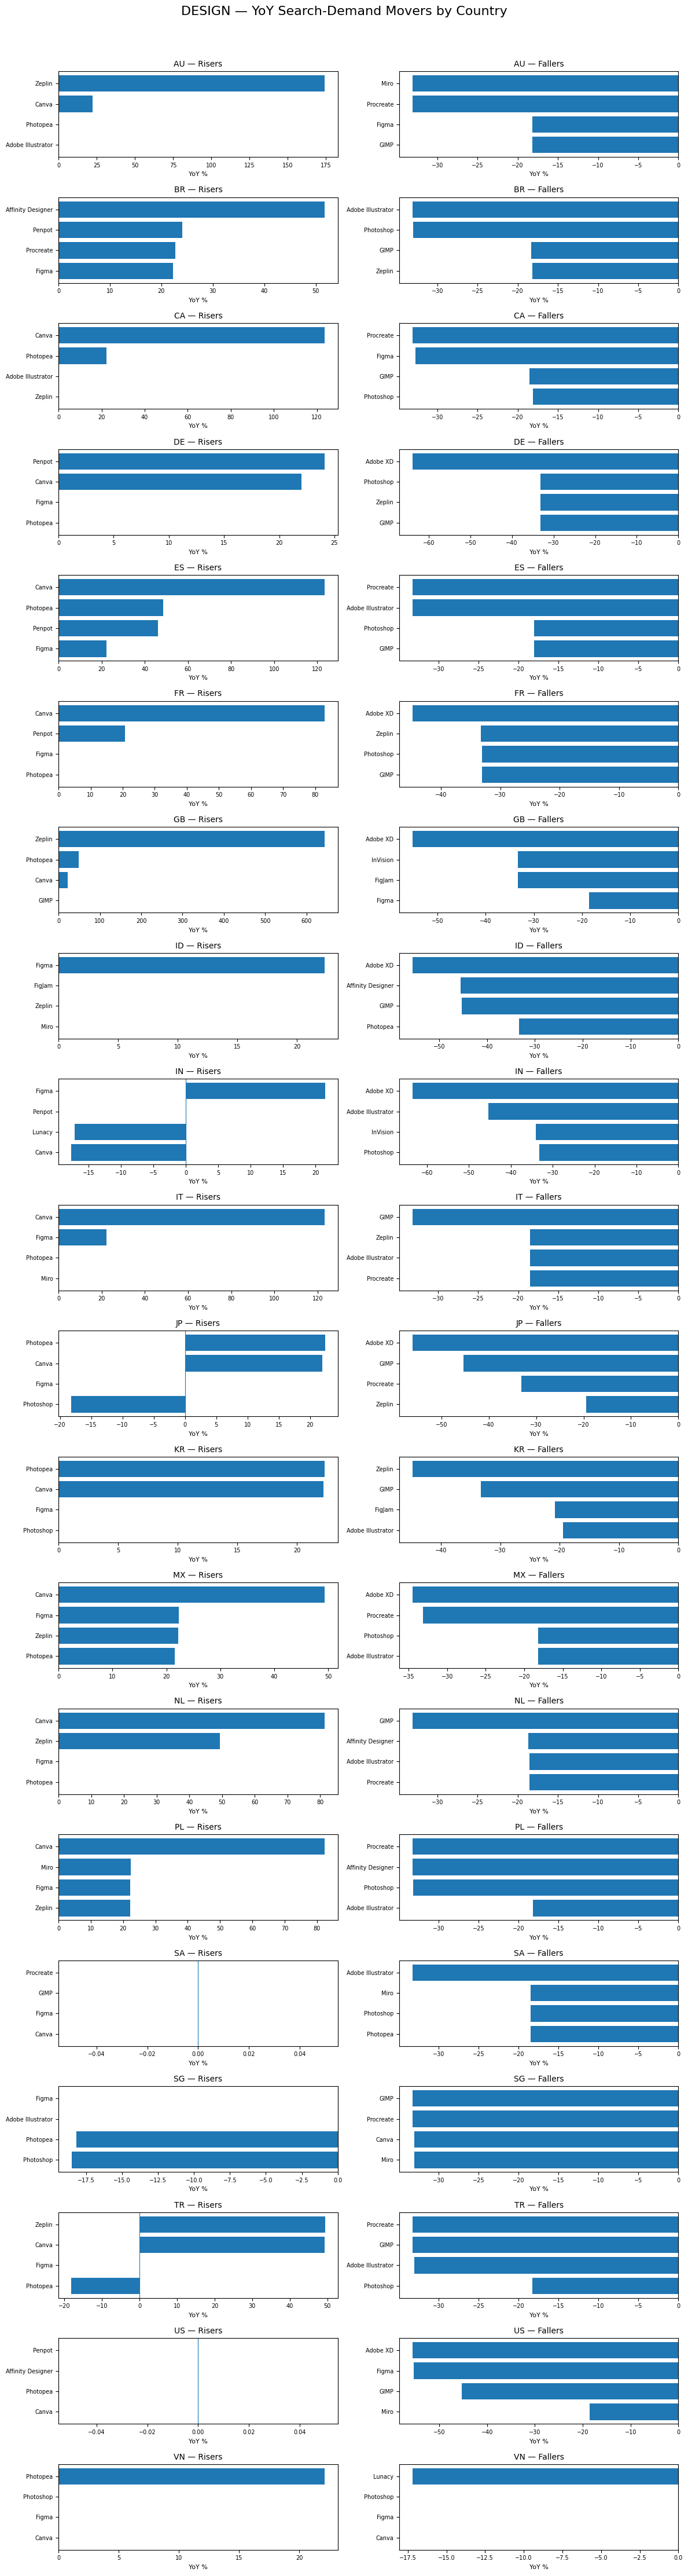

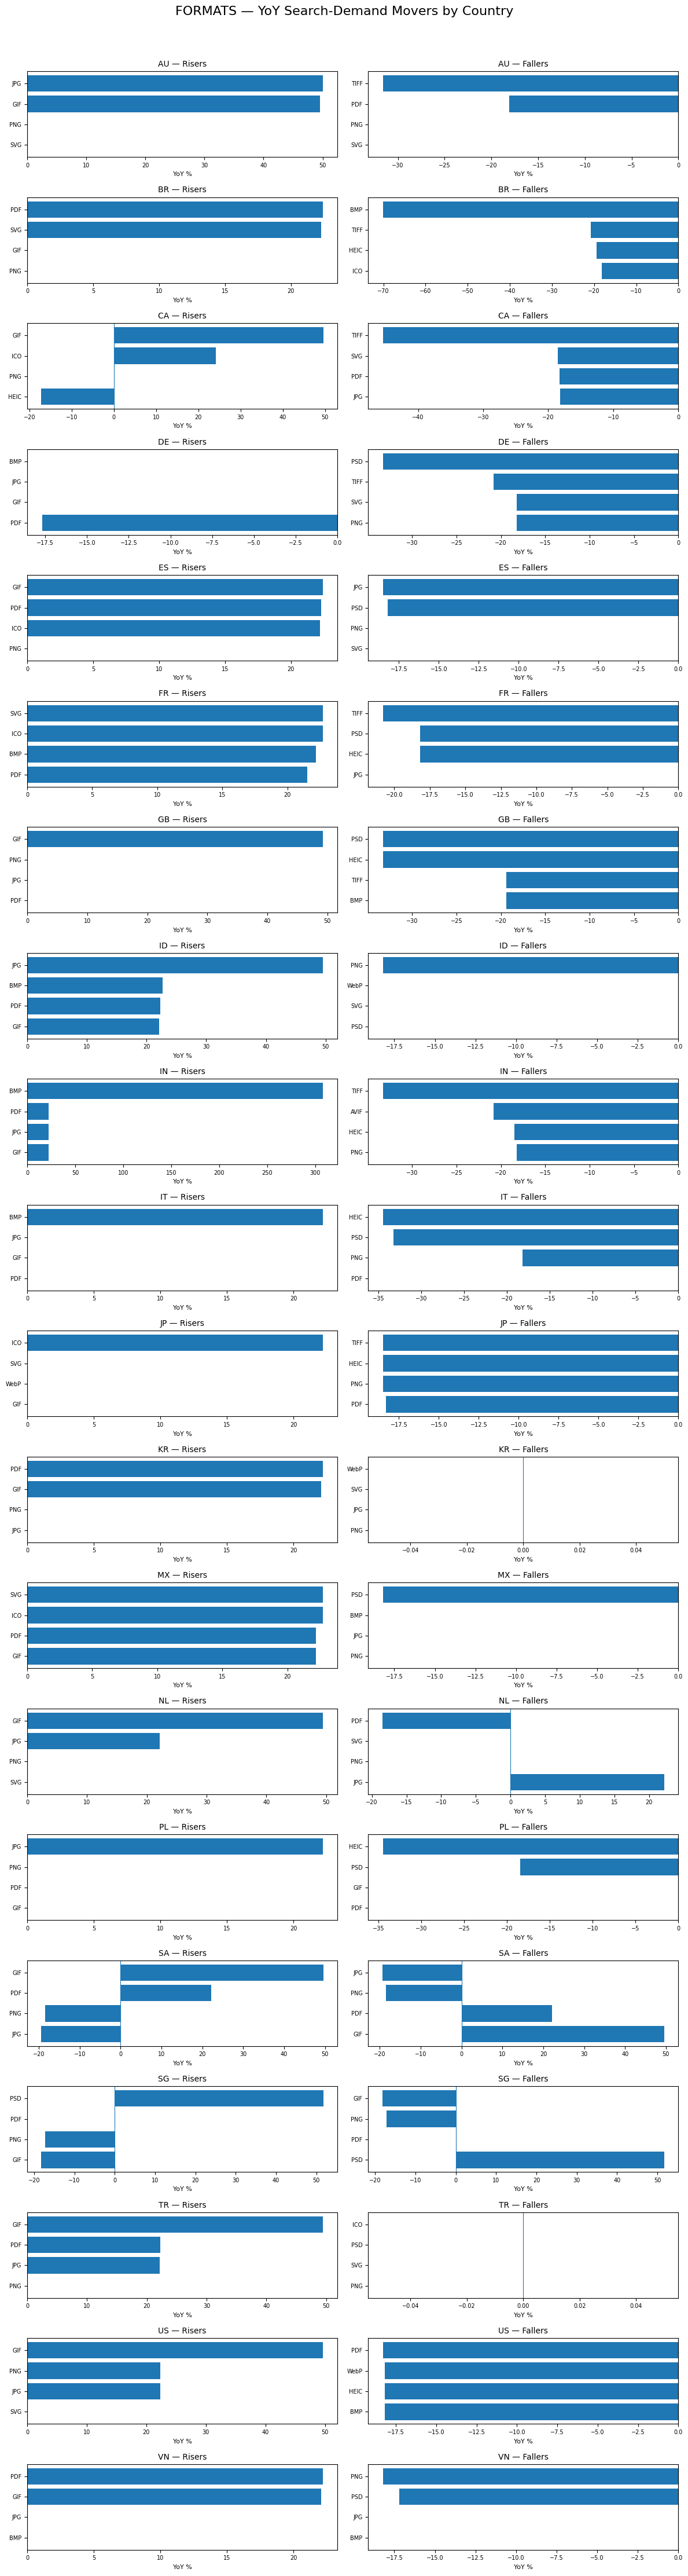

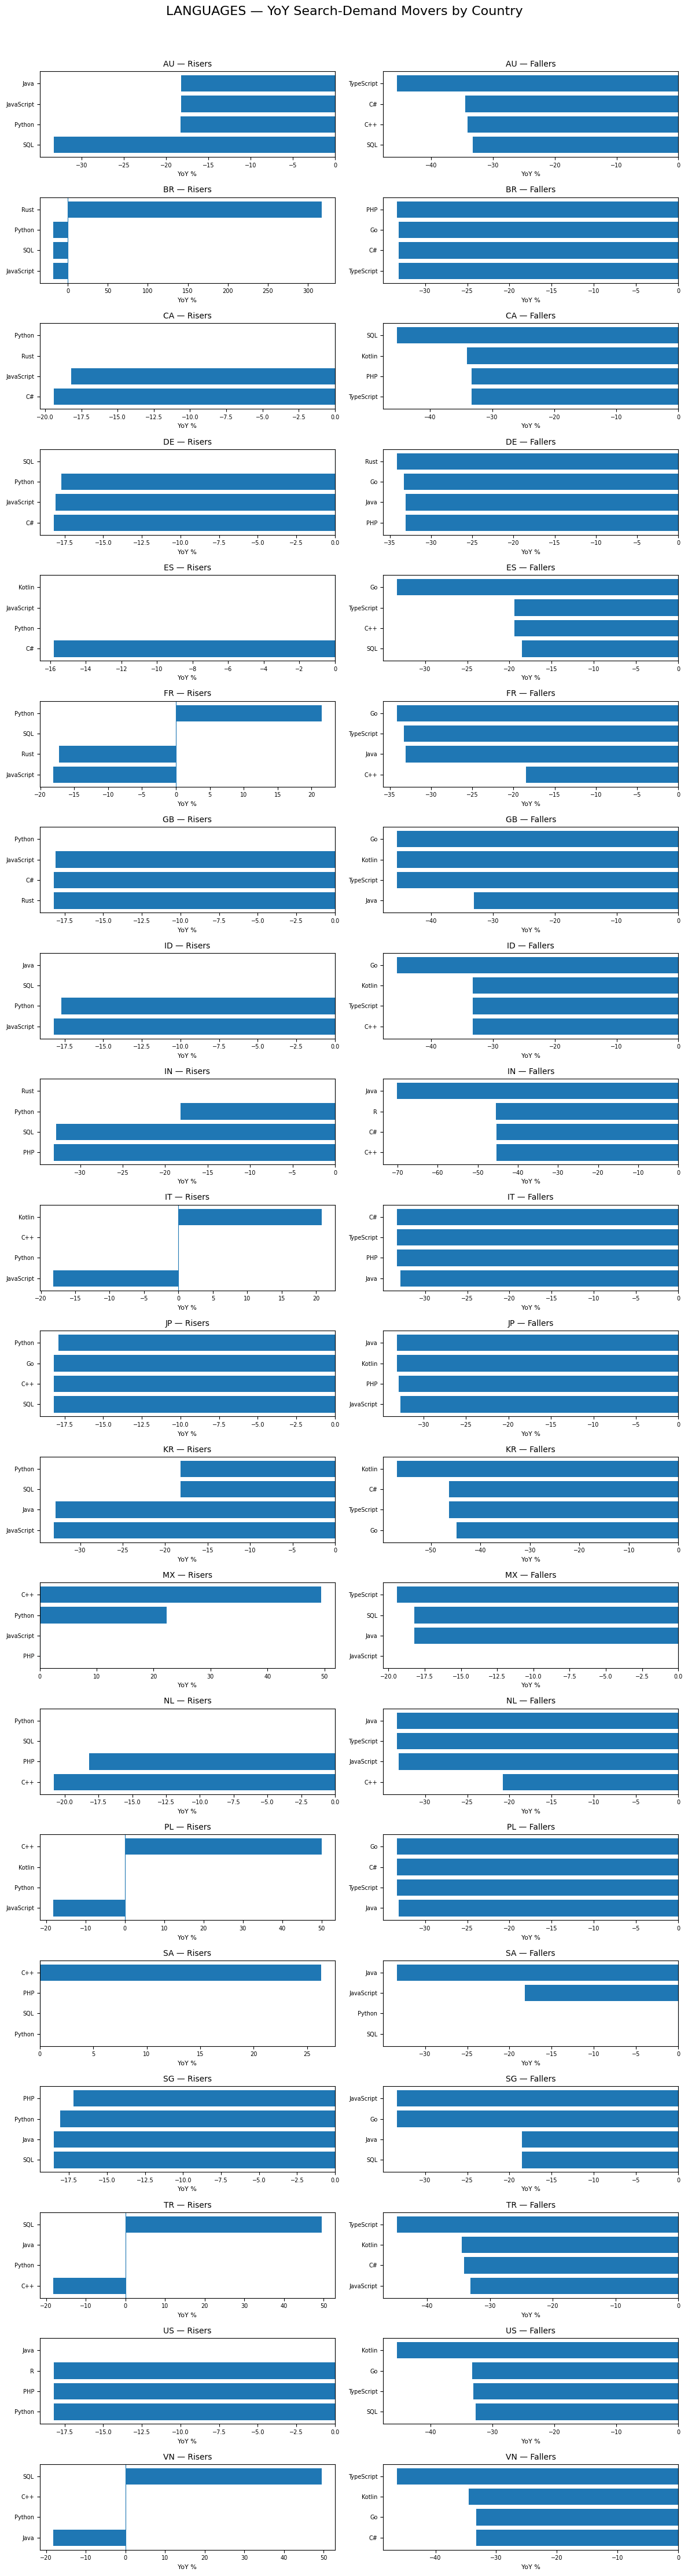

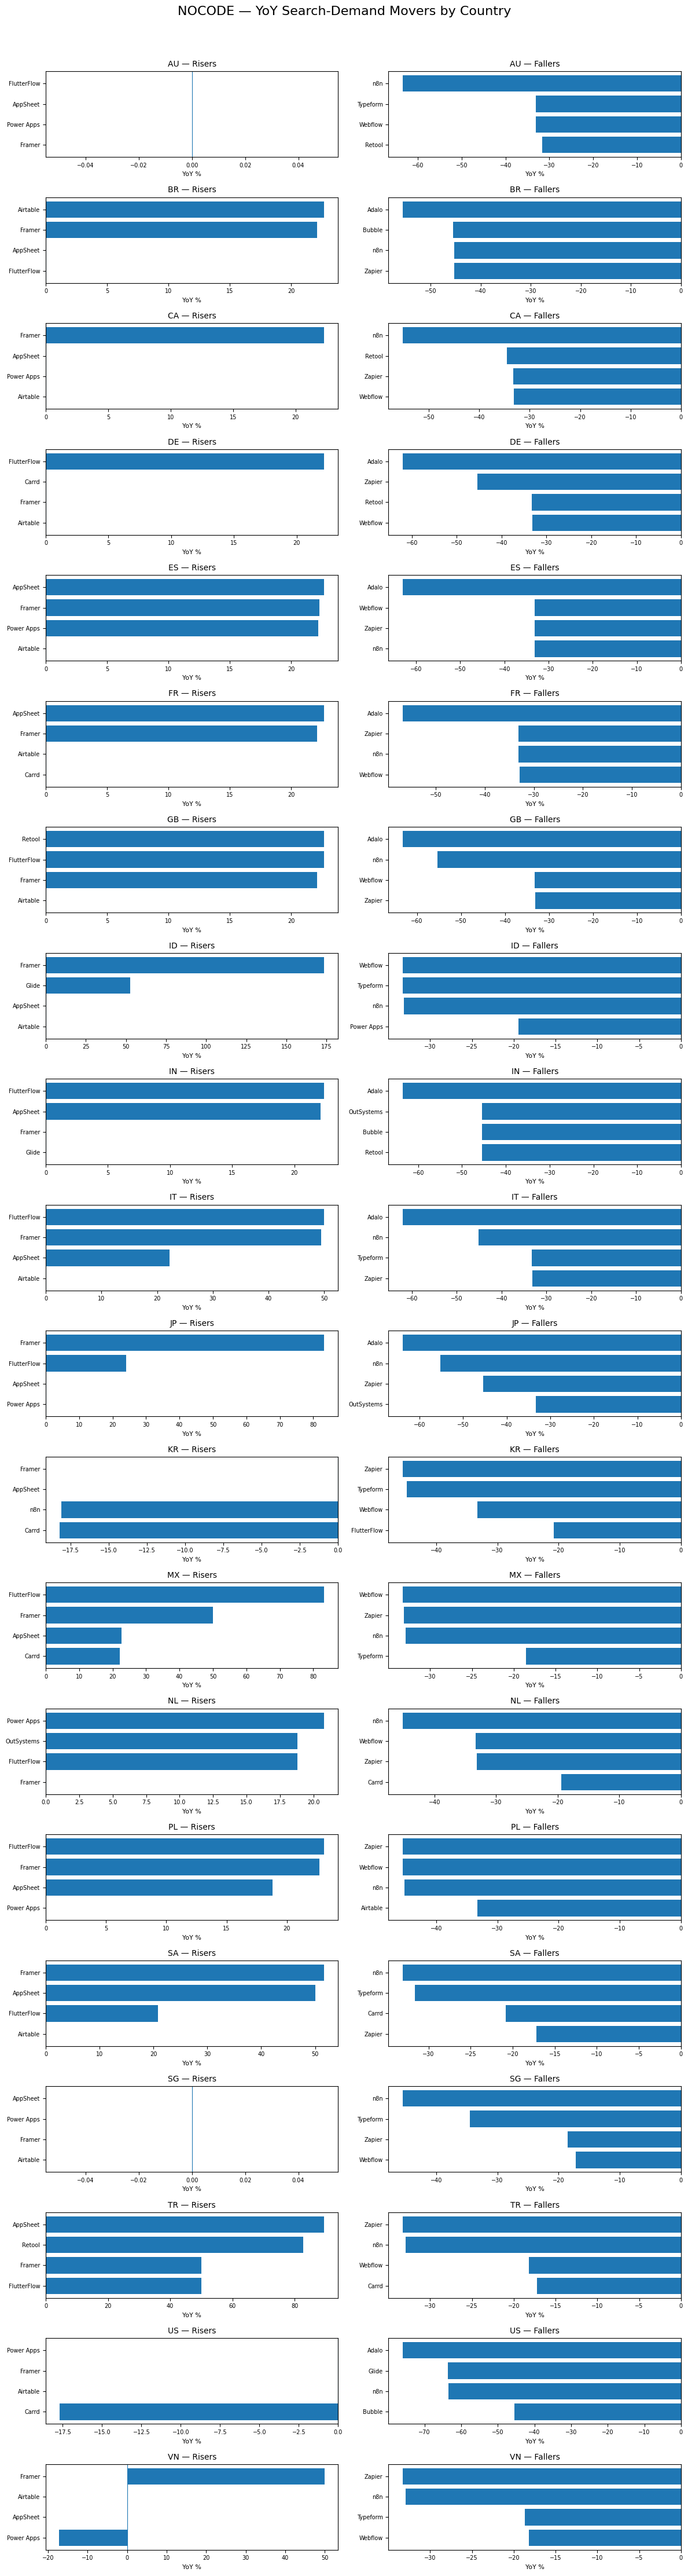

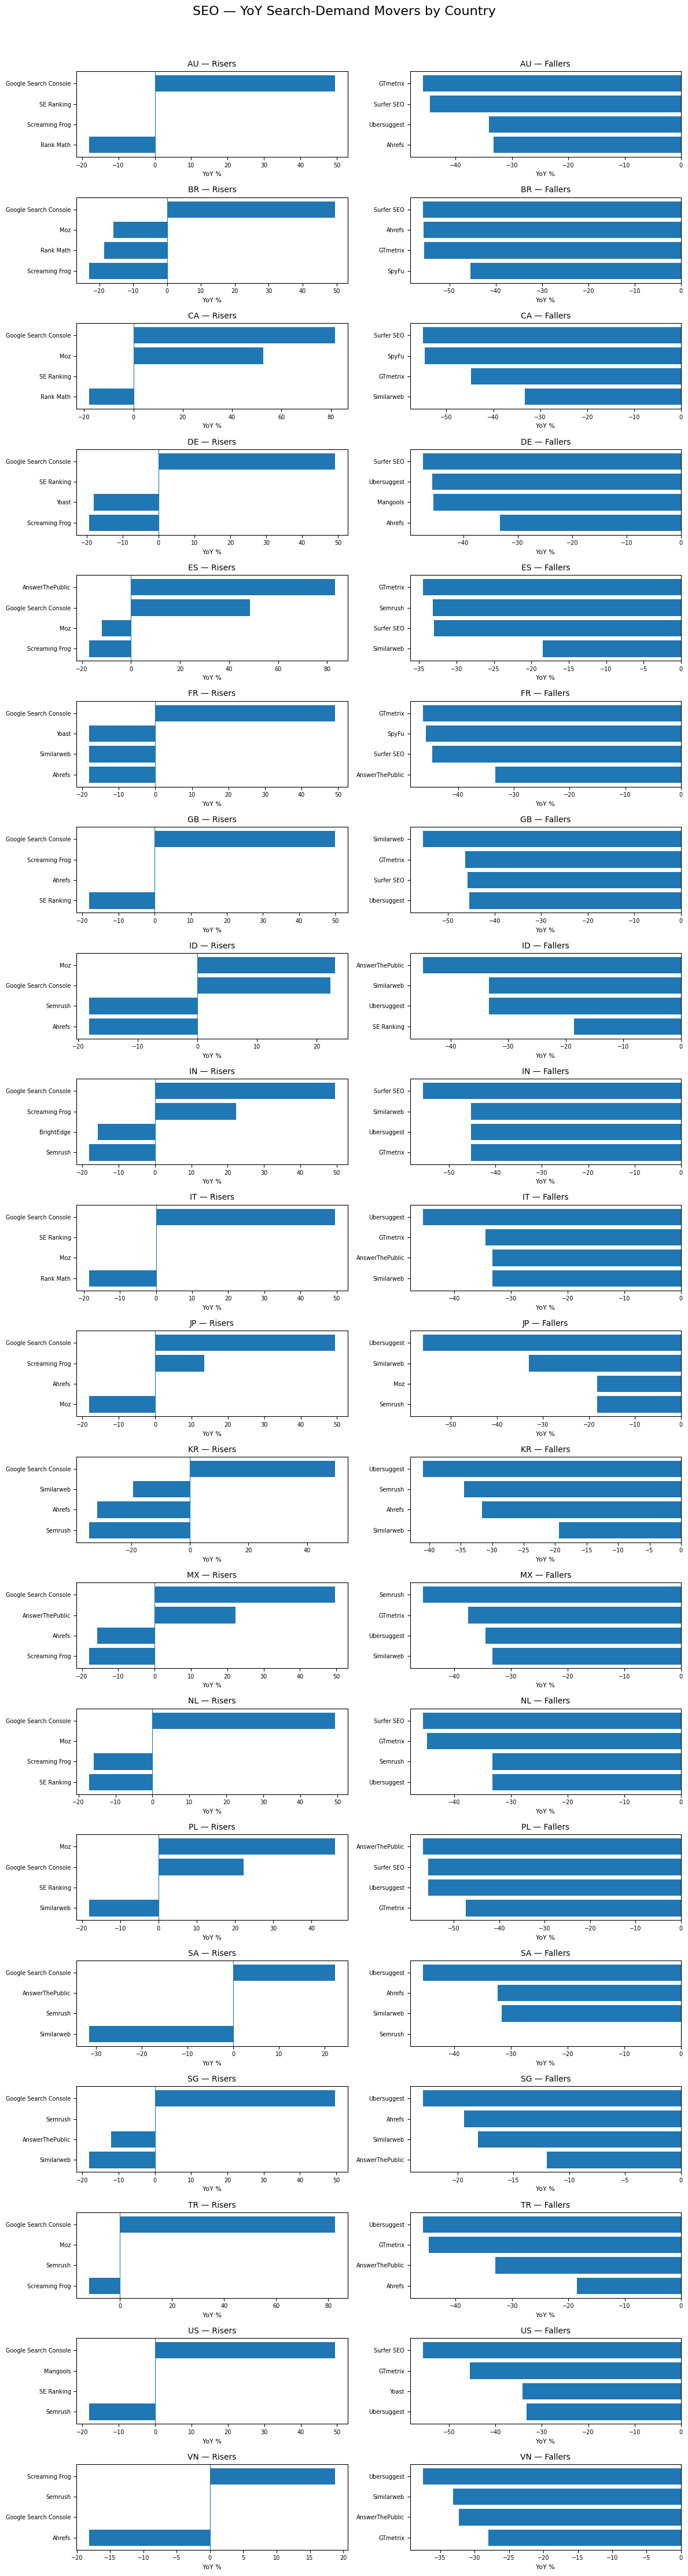

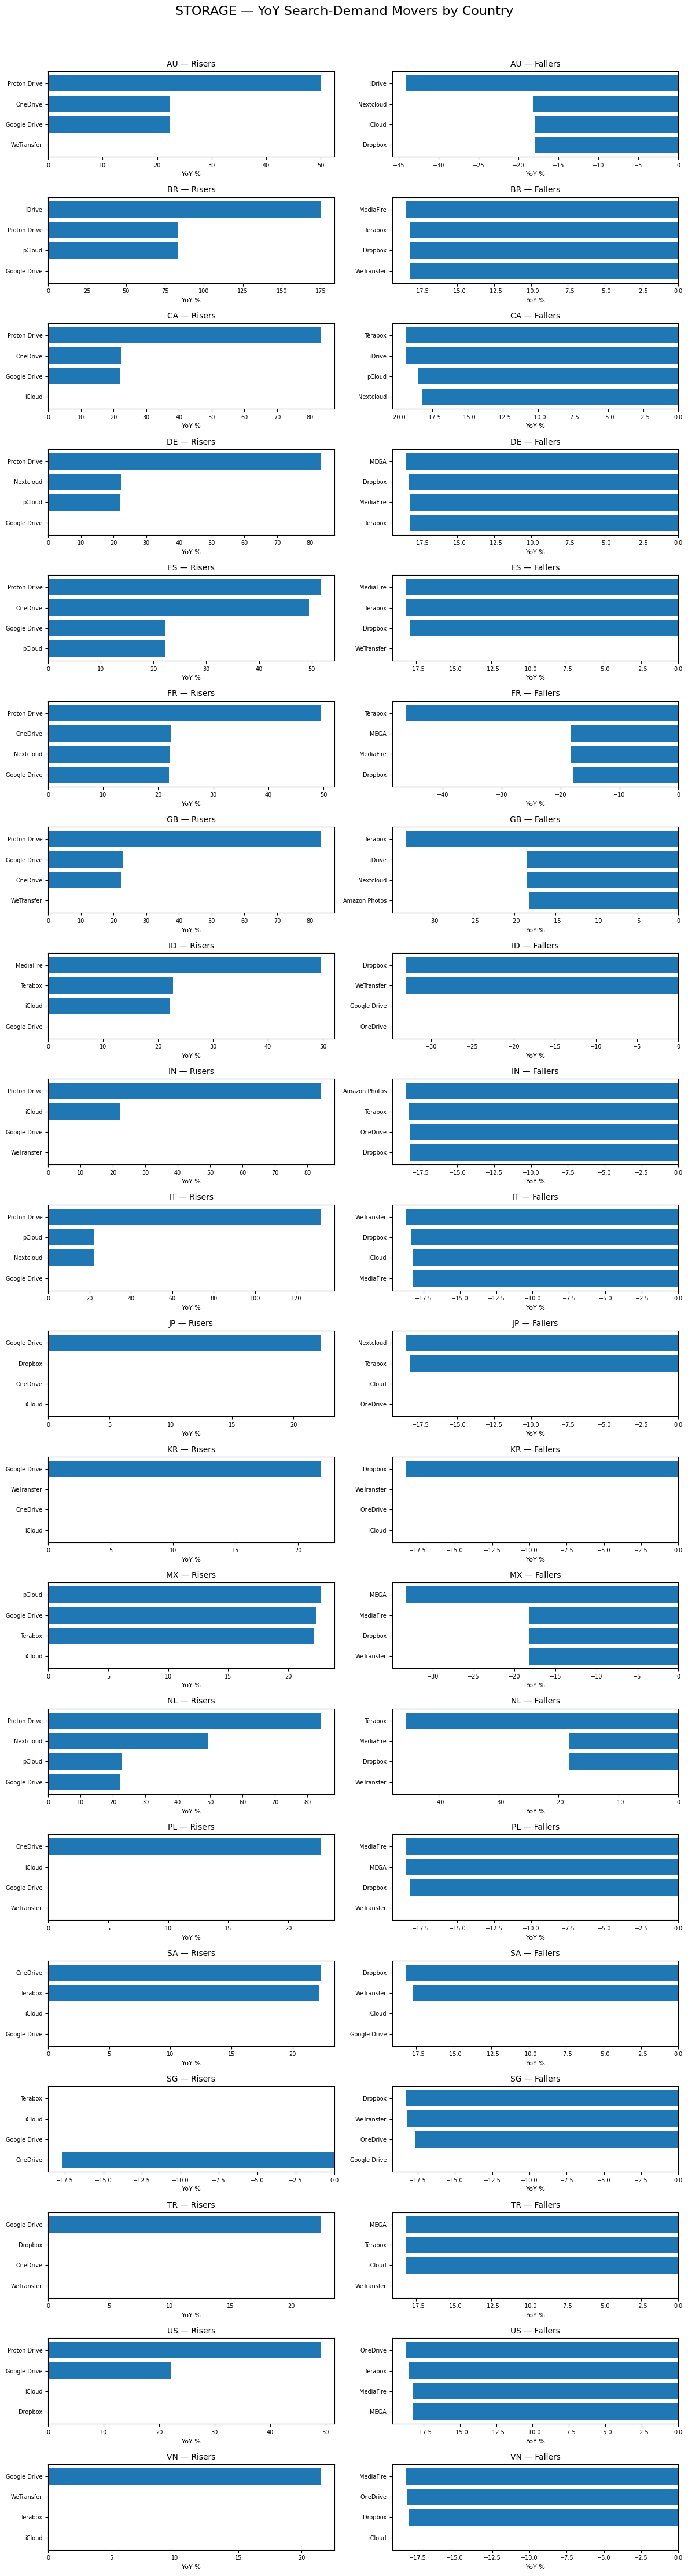

In [18]:
for category in CATEGORIES:

    risers = results[category]["risers"].copy()
    fallers = results[category]["fallers"].copy()

    countries = sorted(risers["scope"].unique())

    # 2 small charts per country:
    # left = risers, right = fallers
    n_countries = len(countries)

    fig, axes = plt.subplots(
        n_countries,
        2,
        figsize=(12, n_countries * 2.2)
    )

    # Handle the case of only one country
    if n_countries == 1:
        axes = axes.reshape(1, 2)

    fig.suptitle(
        f"{category.upper()} — YoY Search-Demand Movers by Country",
        fontsize=16,
        y=1.01
    )

    for i, country in enumerate(countries):

        # -----------------------------
        # RISERS
        # -----------------------------
        country_risers = (
            risers[risers["scope"] == country]
            .sort_values("yoy_pct", ascending=True)
        )

        axes[i, 0].barh(
            country_risers["brand"],
            country_risers["yoy_pct"]
        )

        axes[i, 0].axvline(0, linewidth=0.8)

        axes[i, 0].set_title(
            f"{country} — Risers",
            fontsize=10
        )

        axes[i, 0].set_xlabel("YoY %", fontsize=8)
        axes[i, 0].tick_params(axis="both", labelsize=7)


        # -----------------------------
        # FALLERS
        # -----------------------------
        country_fallers = (
            fallers[fallers["scope"] == country]
            .sort_values("yoy_pct", ascending=False)
        )

        axes[i, 1].barh(
            country_fallers["brand"],
            country_fallers["yoy_pct"]
        )

        axes[i, 1].axvline(0, linewidth=0.8)

        axes[i, 1].set_title(
            f"{country} — Fallers",
            fontsize=10
        )

        axes[i, 1].set_xlabel("YoY %", fontsize=8)
        axes[i, 1].tick_params(axis="both", labelsize=7)


    plt.tight_layout()
    plt.show()

**AI**

AI: Claude and Gemini show some of the strongest YoY search-demand growth across countries, while several established AI brands also appear among the fallers. The largest percentage increases occur where brands have substantial search volume after filtering.

**Coding**

Coding: Claude Code is a prominent riser across multiple countries, with some markets showing particularly strong growth. Other established coding tools show more modest or flat YoY movement.

**Apps**

Apps: The strongest risers are led by major consumer platforms such as Pinterest, WhatsApp, TikTok, and Reddit in different countries. The results show that growth varies considerably by market, while some established platforms experience declines.

**Crypto**

Crypto: Search demand is generally more mixed in this category, with several major crypto platforms appearing among the fallers. The charts highlight substantial country-level differences in YoY demand.

**Design**

Design: The category shows a mix of growth and decline across countries. Larger established design platforms dominate the search volume, while the strongest YoY movements vary by market.

**Formats**

Formats: Search-demand changes are relatively varied across countries, with different file formats showing increases or decreases depending on the market. The charts highlight the strongest country-level movements rather than overall popularity.

**Languages**

Languages: Programming-language search demand shows mixed YoY movement across countries. Some languages demonstrate strong growth in individual markets, while established languages such as Java, JavaScript, and Python also appear among declining movers in some countries.

**No-code**

No-code: Search demand is mixed across the no-code ecosystem, with automation and app-building platforms showing growth in some countries while other established platforms experience declines.

**SEO**

SEO: Search demand varies considerably by country, with different SEO platforms emerging as the strongest risers or fallers. The results highlight that growth patterns are not uniform across markets.

**Storage**

Storage: Storage brands show differing YoY search-demand movements across countries. The charts identify the platforms experiencing the strongest increases and decreases after applying the search-volume filter.